In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy
from time import perf_counter

``` Pseudocode Algorithm
Algorithm: baseline_max_sublist(A)
Input: A list A of n integers
Output: The maximum contiguous subarray sum

1. max_so_far = negative infinity
2. for i from 0 to n-1:
3.    sum = 0
4.    for j from i to n-1:
5.       sum = A[j] + sum
6.       if sum > max_so_far:
7.          max_so_far = sum
8. return max_so_far

```

In [46]:
# Implement baseline algorithm
def baseline_max_sublist(arr):
    n = len(arr)
    max_so_far = -9999999999999999999999999999999999999999999999999999999999999999999999
    for i in range(0,n):
        sum = 0
        for j in range(i,n):
            sum += arr[j]
            if sum > max_so_far:
                max_so_far = sum
    return max_so_far

print(baseline_max_sublist([-2, 1, -3, 4, -1, 2, 1, -5, 4]))

6


In [47]:
# Implement target algorithm
def kadane_max_sublist(arr):
    n = len(arr)
    max_so_far = -9999999999999999999999999999999999999999999999999999999999999999999999
    current_max = 0
    for i in range(0,n-1):
        current_max += arr[i]
        if current_max > max_so_far:
            max_so_far = current_max
        if current_max < 0:
            current_max = 0
    return max_so_far

print(kadane_max_sublist([-2, 1, -3, 4, -1, 2, 1, -5, 4]))

6


In [48]:
# helper function
def helper_function(n):
    random_list = []
    for i in range(n):
        random_list.append(numpy.random.randint(-100, 101))
    return random_list

print(helper_function(5))

def helper_function_lists(n):
    random_list = []
    for i in n:
        random_list.append(helper_function(i))
    return random_list

print(helper_function_lists(abs(number) for number in helper_function(5)))



[-70, -79, 81, -36, 47]
[[47, -60, 95, -35, 32, -83, -3, -55, 58, 25, -38, -10, -3, 15, -97, 31, 44, -28, 1, -20, -13, -75, 92], [-36, 12, -76, -86, -38, 1, 29, -22, -6, 74, 3, -79, 46, 60], [-19], [55, 21, 98, 96, -52, 67, 83, 18, -15, -92, 58, -97, -4, -60, 57, 84, 14, -79, -6, -46, -4, -93, -70, -54, -88, 43, -85, 64, -48, -90, -97, 65, -100, 74, -72, -42, -55, -18, 47, -13, 14], [18, 78, -24, 35, -22, -27, 72, 18, 48, 98, -50, -24, -83, 58, 28, -66, 28, 44, -77, -47, -81, -67, 70, -30, 48, 29, 79, 81, 63, 48, 35, 98, -1, 16, -92, -45, -62, 51, 69, -75]]


baseline: [(100, 0.0002751074032858014), (500, 0.008683612302411348), (1000, 0.033621243594097905), (2500, 0.21761976609705017), (5000, 0.9016853724053362), (10000, 3.4718890622025356)]
kadane: [(100, 6.743799895048142e-06), (500, 3.5038904752582314e-05), (1000, 8.401299419347197e-05), (2500, 0.00019676939700730145), (5000, 0.00037117889733053746), (10000, 0.0008549046033294871)]


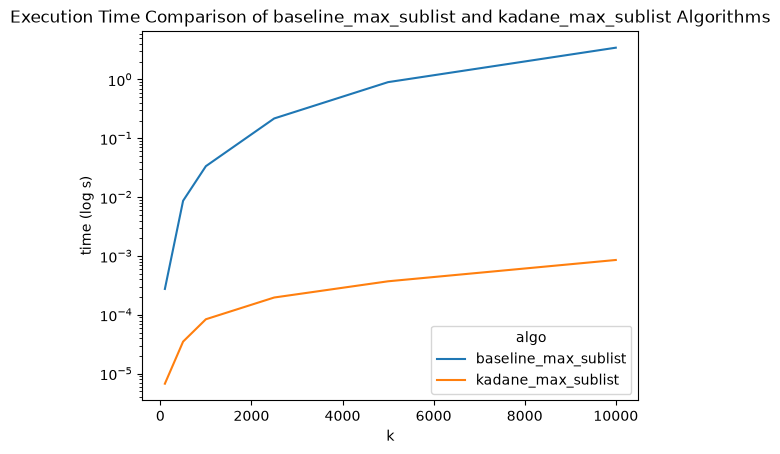

In [49]:
# benchmarking
baseline_times = []
kadane_times = []

def benchmark_algo_multi(algo, test_cases, repeat=1):
    times = []
    for i in test_cases:
        total_duration = 0
        for _ in range(repeat):
            start = perf_counter()
            algo(i)
            end = perf_counter()
            duration = end - start
            total_duration += duration
        avg_time = total_duration / repeat
        times.append((len(i), avg_time))
    return times

repeats = [100, 500, 1000, 2500, 5000, 10000]
baseline_max_sublist_times = benchmark_algo_multi(baseline_max_sublist, helper_function_lists(repeats), 10)
kadane_max_sublist_times = benchmark_algo_multi(kadane_max_sublist, helper_function_lists(repeats), 10)

print(f"baseline: {baseline_max_sublist_times}")
print(f"kadane: {kadane_max_sublist_times}")

df_base = pd.DataFrame(baseline_max_sublist_times, columns = ["k", "time"])
df_base['algo'] = "baseline_max_sublist"

df_kadane = pd.DataFrame(kadane_max_sublist_times, columns = ["k", "time"])
df_kadane['algo'] = "kadane_max_sublist"

df = pd.concat([df_base, df_kadane], ignore_index=True)

sns.lineplot(data=df, x="k", y="time", hue="algo")
plt.xlabel("k")
plt.ylabel("time (log s)")
plt.title("Execution Time Comparison of baseline_max_sublist and kadane_max_sublist Algorithms")
plt.yscale("log")
plt.show()
